# 05 - Filter Obvious Anomalies

Removes only clear errors in `duration_sec` and technical metadata.

Rules for removal:
- missing or invalid `duration_sec` (`NaN` or `<= 0`)
- invalid `fps` / `length_frames` (if columns are present)
- strong inconsistency between `duration_sec` and `length_frames / fps` (threshold computed from data)
- globally extreme durations (very conservative bounds computed automatically)

Output:
1. Summary plots of removed records.
2. Two CSV files: clean dataset and removed records with removal reasons.

## 1. Set Up Environment and Dependencies

Import libraries, set display preferences, and show version information used in this run.

In [8]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
plt.style.use("ggplot")

print("Python imports loaded.")
print(f"pandas={pd.__version__}, numpy={np.__version__}")

Python imports loaded.
pandas=2.3.3, numpy=2.4.4


## 2. Define Project Configuration

Set constants for input/output paths, detection thresholds, and policy flags.

In [9]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

INPUT_CSV = PROJECT_ROOT / "merged_datasets" / "universal_metadata_has_video.csv"
OUTPUT_CLEAN_CSV = PROJECT_ROOT / "merged_datasets" / "universal_metadata_anomaly_clean.csv"
OUTPUT_REMOVED_CSV = PROJECT_ROOT / "merged_datasets" / "universal_metadata_anomaly_removed.csv"

CONFIG: Dict[str, float | int] = {
    "target_col": "duration_sec",
    "group_col": "label",
    "extreme_low_q": 0.001,
    "extreme_high_q": 0.999,
    "consistency_error_q": 0.995,
    "min_consistency_error_sec": 0.5,
    "random_seed": 42,
}

np.random.seed(int(CONFIG["random_seed"]))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_CSV:", INPUT_CSV)
print("Mode: automatic obvious-error filtering")

PROJECT_ROOT: C:\Users\Magda\source\repos\private\szum
INPUT_CSV: C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_has_video.csv
Mode: automatic obvious-error filtering


## 3. Implement Core Utility Functions

Helper functions for validation, per-label outlier scoring (IQR and MAD), reason building, and plotting.

In [10]:
def validate_input(df: pd.DataFrame) -> None:
    required_cols = ["label", "duration_sec"]
    missing_cols = []

    for col in required_cols:
        if col not in df.columns:
            missing_cols.append(col)

    if len(missing_cols) > 0:
        raise ValueError(f"Missing required columns: {missing_cols}")


def build_reason(row: pd.Series) -> str:
    reasons = []

    if bool(row.get("invalid_duration", False)):
        reasons.append("invalid_duration")

    if bool(row.get("invalid_fps", False)):
        reasons.append("invalid_fps")

    if bool(row.get("invalid_length_frames", False)):
        reasons.append("invalid_length_frames")

    if bool(row.get("is_consistency_outlier", False)):
        reasons.append("duration_frames_fps_mismatch")

    if bool(row.get("is_extreme_duration", False)):
        reasons.append("extreme_duration_global")

    return "; ".join(reasons)


def plot_audit_views(audit_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    kept = audit_df[audit_df["is_anomaly"] == False]["duration_sec"].dropna()
    removed = audit_df[audit_df["is_anomaly"] == True]["duration_sec"].dropna()

    axes[0].hist(kept, bins=40, alpha=0.7, label="kept")
    axes[0].hist(removed, bins=40, alpha=0.8, label="removed")
    axes[0].set_title("Duration Distribution")
    axes[0].set_xlabel("duration_sec")
    axes[0].set_ylabel("count")
    axes[0].legend()

    label_rates = (
        audit_df.groupby("label", dropna=False)["is_anomaly"]
        .mean()
        .sort_values(ascending=False)
        .head(20)
    )

    axes[1].bar(range(len(label_rates)), label_rates.values)
    axes[1].set_xticks(range(len(label_rates)))
    axes[1].set_xticklabels(label_rates.index, rotation=70, ha="right")
    axes[1].set_title("Top 20 Labels by Removal Rate")
    axes[1].set_ylabel("removal_rate")

    plt.tight_layout()
    plt.show()


def plot_removed_by_signer_and_source(removed_df: pd.DataFrame, top_n: int = 20) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    if "signer_id" in removed_df.columns:
        signer_counts = (
            removed_df.groupby("signer_id")["label"]
            .nunique()
            .sort_values(ascending=False)
            .head(top_n)
        )
        axes[0].bar(range(len(signer_counts)), signer_counts.values)
        axes[0].set_xticks(range(len(signer_counts)))
        axes[0].set_xticklabels(signer_counts.index.astype(str), rotation=70, ha="right")
        axes[0].set_title("Removed labels per signer_id")
        axes[0].set_ylabel("unique labels removed")
    else:
        axes[0].text(0.5, 0.5, "No signer_id column", ha="center", va="center")
        axes[0].set_title("Removed labels per signer_id")
        axes[0].set_axis_off()

    if "source" in removed_df.columns:
        source_counts = (
            removed_df.groupby("source")["label"]
            .nunique()
            .sort_values(ascending=False)
            .head(top_n)
        )
        axes[1].bar(range(len(source_counts)), source_counts.values)
        axes[1].set_xticks(range(len(source_counts)))
        axes[1].set_xticklabels(source_counts.index.astype(str), rotation=70, ha="right")
        axes[1].set_title("Removed labels per source")
        axes[1].set_ylabel("unique labels removed")
    else:
        axes[1].text(0.5, 0.5, "No source column", ha="center", va="center")
        axes[1].set_title("Removed labels per source")
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()

## 4. Build the Main Implementation Function

Run preprocessing, per-label anomaly detection, and produce clean/removed splits.

In [11]:
def run_anomaly_pipeline(input_csv: Path, cfg: Dict[str, float | int]) -> Dict[str, pd.DataFrame]:
    df = pd.read_csv(input_csv)
    df = df.copy()
    validate_input(df)

    target_col = str(cfg["target_col"])

    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
    df["invalid_duration"] = df[target_col].isna() | (df[target_col] <= 0)

    if "fps" in df.columns:
        df["fps"] = pd.to_numeric(df["fps"], errors="coerce")
        df["invalid_fps"] = df["fps"].notna() & (df["fps"] <= 0)
    else:
        df["invalid_fps"] = False

    if "length_frames" in df.columns:
        df["length_frames"] = pd.to_numeric(df["length_frames"], errors="coerce")
        df["invalid_length_frames"] = df["length_frames"].notna() & (df["length_frames"] <= 0)
    else:
        df["invalid_length_frames"] = False

    has_tech_cols = ("fps" in df.columns) and ("length_frames" in df.columns)

    if has_tech_cols:
        valid_pair = (
            df["fps"].notna()
            & (df["fps"] > 0)
            & df["length_frames"].notna()
            & (df["length_frames"] > 0)
            & df[target_col].notna()
            & (df[target_col] > 0)
        )

        df["duration_from_frames"] = np.where(valid_pair, df["length_frames"] / df["fps"], np.nan)
        df["consistency_error_sec"] = (df[target_col] - df["duration_from_frames"]).abs()

        if valid_pair.any():
            q = float(cfg["consistency_error_q"])
            auto_thr = float(df.loc[valid_pair, "consistency_error_sec"].quantile(q))
            min_thr = float(cfg["min_consistency_error_sec"])
            if auto_thr < min_thr:
                auto_thr = min_thr
            df["is_consistency_outlier"] = df["consistency_error_sec"] > auto_thr
        else:
            df["is_consistency_outlier"] = False
    else:
        df["duration_from_frames"] = np.nan
        df["consistency_error_sec"] = np.nan
        df["is_consistency_outlier"] = False

    valid_duration = df.loc[df[target_col].notna() & (df[target_col] > 0), target_col]

    if len(valid_duration) > 0:
        low_thr = float(valid_duration.quantile(float(cfg["extreme_low_q"])))
        high_thr = float(valid_duration.quantile(float(cfg["extreme_high_q"])))
    else:
        low_thr = 0.0
        high_thr = np.inf

    df["extreme_low_thr"] = low_thr
    df["extreme_high_thr"] = high_thr
    df["is_extreme_duration"] = (df[target_col] < low_thr) | (df[target_col] > high_thr)

    df["is_anomaly"] = (
        df["invalid_duration"]
        | df["invalid_fps"]
        | df["invalid_length_frames"]
        | df["is_consistency_outlier"]
        | df["is_extreme_duration"]
    )

    df["removal_reason"] = df.apply(build_reason, axis=1)

    clean_df = df[df["is_anomaly"] == False].copy()
    removed_df = df[df["is_anomaly"] == True].copy()

    summary = pd.DataFrame(
        {
            "rows_total": [len(df)],
            "rows_removed": [len(removed_df)],
            "rows_kept": [len(clean_df)],
            "removed_ratio": [len(removed_df) / max(len(df), 1)],
            "labels_total": [df["label"].nunique(dropna=True)],
            "extreme_low_thr_sec": [low_thr],
            "extreme_high_thr_sec": [high_thr],
        }
    )

    return {
        "audit_df": df,
        "clean_df": clean_df,
        "removed_df": removed_df,
        "summary_df": summary,
    }

## 5. Run a First End-to-End Execution

Execute the pipeline, print checkpoints, and visualize anomaly patterns.

Execution checkpoints:
- input rows: 12140
- removed rows: 2041
- kept rows: 10099
- removed ratio: 0.1681


,rows_total,rows_removed,rows_kept,removed_ratio,labels_total,extreme_low_thr_sec,extreme_high_thr_sec
0,12140,2041,10099,0.168122,2000,0.834,7.598675


,label,duration_sec,label_mean_duration_sec,invalid_duration,invalid_fps,invalid_length_frames,is_consistency_outlier,is_extreme_duration,removal_reason
1,book,NaN,2.942571,True,False,False,False,False,invalid_duration
2,book,NaN,2.942571,True,False,False,False,False,invalid_duration
9,book,NaN,2.942571,True,False,False,False,False,invalid_duration
10,book,NaN,2.942571,True,False,False,False,False,invalid_duration
13,drink,NaN,3.057778,True,False,False,False,False,invalid_duration
14,drink,NaN,3.057778,True,False,False,False,False,invalid_duration
15,drink,NaN,3.057778,True,False,False,False,False,invalid_duration
16,drink,NaN,3.057778,True,False,False,False,False,invalid_duration
18,drink,NaN,3.057778,True,False,False,False,False,invalid_duration
19,drink,NaN,3.057778,True,False,False,False,False,invalid_duration


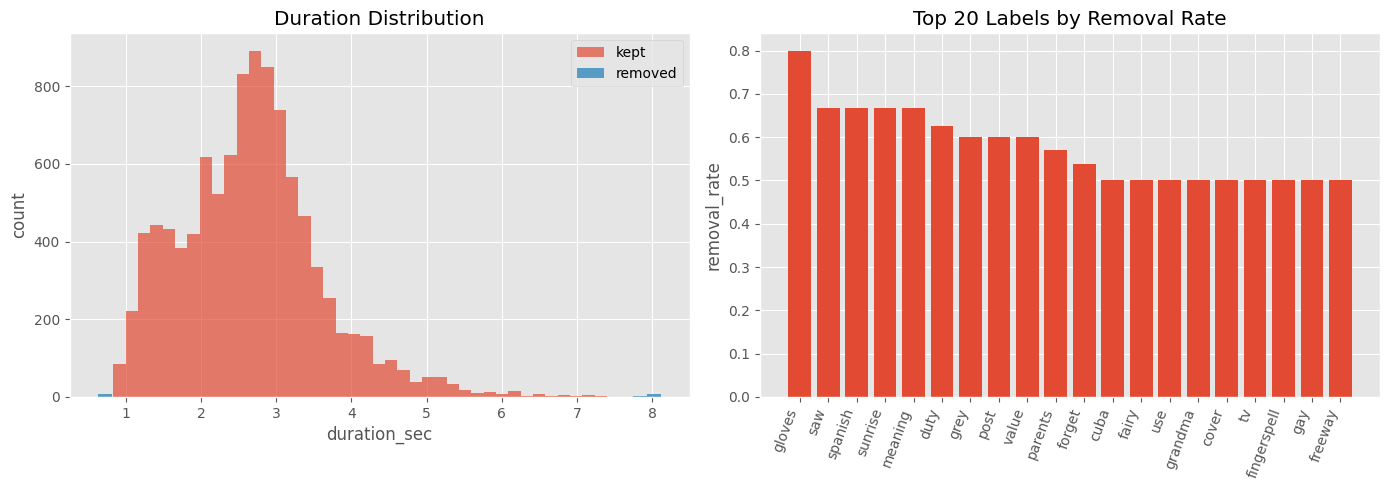

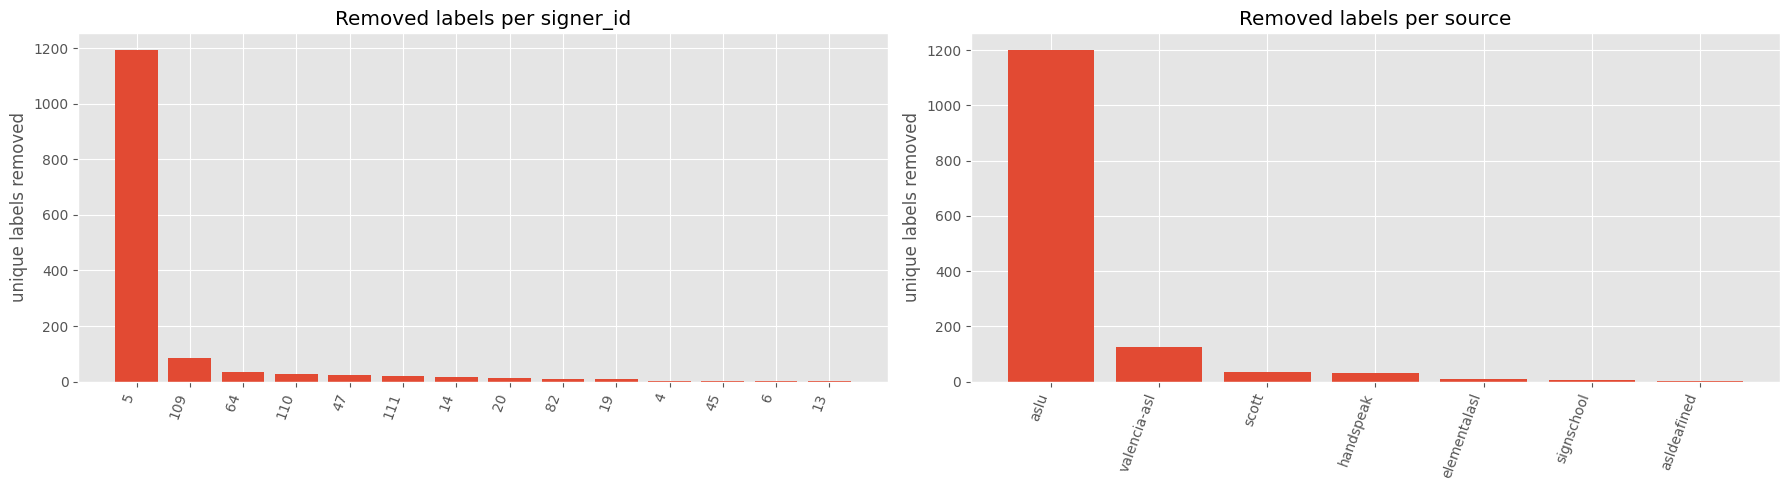

In [12]:
results = run_anomaly_pipeline(INPUT_CSV, CONFIG)

audit_df = results["audit_df"]
clean_df = results["clean_df"]
removed_df = results["removed_df"]
summary_df = results["summary_df"]

print("Execution checkpoints:")
print("- input rows:", len(audit_df))
print("- removed rows:", len(removed_df))
print("- kept rows:", len(clean_df))
print("- removed ratio:", round(len(removed_df) / max(len(audit_df), 1), 4))

display(summary_df)

label_mean_duration = (
    audit_df.groupby("label", dropna=False)["duration_sec"]
    .mean()
    .rename("label_mean_duration_sec")
)

removed_preview = removed_df.join(label_mean_duration, on="label")

display(
    removed_preview[
        [
            "label",
            "duration_sec",
            "label_mean_duration_sec",
            "invalid_duration",
            "invalid_fps",
            "invalid_length_frames",
            "is_consistency_outlier",
            "is_extreme_duration",
            "removal_reason",
        ]
    ].head(20)
)

plot_audit_views(audit_df)
plot_removed_by_signer_and_source(removed_df)

## 6. Validate Outputs with Assertions

Run basic quality gates so failures appear early during notebook execution.

In [13]:
assert len(audit_df) == len(clean_df) + len(removed_df), "Row count mismatch after split."
assert "removal_reason" in removed_df.columns, "Removed dataset must include removal_reason."
assert removed_df["is_anomaly"].all(), "Removed rows must be anomalies."
assert (~clean_df["is_anomaly"]).all(), "Clean rows must not be anomalies."
assert OUTPUT_CLEAN_CSV.parent.exists(), "Output directory does not exist."

print("All validation assertions passed.")

All validation assertions passed.


## 7. Persist Results for Next Iteration

Save clean and removed datasets, keeping all audit columns and explicit removal reasons.

In [14]:
clean_df.to_csv(OUTPUT_CLEAN_CSV, index=False)
removed_df.to_csv(OUTPUT_REMOVED_CSV, index=False)

print("Saved:")
print("-", OUTPUT_CLEAN_CSV)
print("-", OUTPUT_REMOVED_CSV)

# Optional compact audit summary for quick external inspection.
audit_preview_path = OUTPUT_REMOVED_CSV.with_name("universal_metadata_anomaly_audit_summary.csv")
(
    audit_df.groupby("label", dropna=False)
    .agg(
        rows_total=("label", "size"),
        rows_removed=("is_anomaly", "sum"),
        anomaly_rate=("is_anomaly", "mean"),
        median_duration=("duration_sec", "median"),
    )
    .sort_values("anomaly_rate", ascending=False)
    .to_csv(audit_preview_path)
)
print("-", audit_preview_path)

Saved:
- C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_anomaly_clean.csv
- C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_anomaly_removed.csv
- C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_anomaly_audit_summary.csv
